In [ ]:
from utils_task1 import RedditDataset

dataset = RedditDataset(path="Reddit")

batch_size = 2048
lr = 1e-4
num_epochs = 20

Numero di nodi:  232965
Numero di archi:  114615892
Dimensionalità delle features:  602
Di queste, le prime 300 l'embedding di Glove del titolo, le seconde 300 l'embedding di Glove medio di tutti i commenti
La feature 601 è lo score di reddit e la 602 è il numero di commenti
--------------------------------------------------------------------
Analisi della cardinalità delle classi e bilanciamento del dataset
classe  0 :  13101 -- 5.62%
classe  1 :   3550 -- 1.52%
classe  2 :   3302 -- 1.42%
classe  3 :  15181 -- 6.52%
classe  4 :   2322 -- 1.00%
classe  5 :   3597 -- 1.54%
classe  6 :   3952 -- 1.70%
classe  7 :   2138 -- 0.92%
classe  8 :  11187 -- 4.80%
classe  9 :   2246 -- 0.96%
classe 10 :   4928 -- 2.12%
classe 11 :   2964 -- 1.27%
classe 12 :   1696 -- 0.73%
classe 13 :   2731 -- 1.17%
classe 14 :   4854 -- 2.08%
classe 15 :  28272 -- 12.14%
classe 16 :   1003 -- 0.43%
classe 17 :   2639 -- 1.13%
classe 18 :  13999 -- 6.01%
classe 19 :  10308 -- 4.42%
classe 20 :   1596 -- 0.69%

VALUTAZIONE DELLA DENSITÀ LOCALE
Nodo Target Centrale analizzato: 186799
Cardinalità del sotto-grafo: 200 nodi
Numero di archi locali interni: 5879


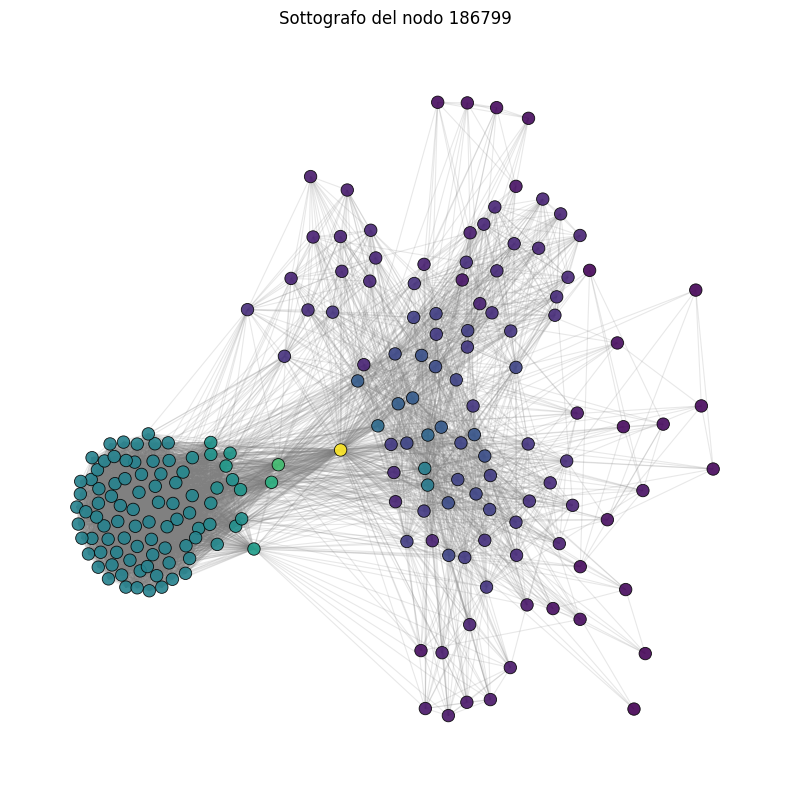

In [2]:
dataset.visualize(max_nodes=200)

In [3]:
train_loader, val_loader, test_loader = dataset.get_node_loaders(batch_size=batch_size)

In [ ]:
import torch
from utils_task1 import train_loop, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inizio Task 1 su dispositivo: {device}")
data = dataset.dataset
stats = dataset.stats

# Calcolo dei pesi inversamente proporzionali alla frequenza di ciascuna classe per bilanciare la loss durante l'addestramento
labels_train = data.y[data.train_mask]
conteggi = torch.bincount(labels_train)
pesi_classi = 1.0 / (conteggi.float() + 1e-6)
pesi_classi = pesi_classi / pesi_classi.sum()
pesi_classi = pesi_classi.to(device)

Inizio Task 1 su dispositivo: cuda


Primo tentativo con GCNConv

In [ ]:
from utils_task1 import GCNmodel

model = GCNmodel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_GCN.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 01/10 | Loss Train: 3.37 | Val Loss: 2.71 | Val F1 Macro: 0.31 | Val Precision: 0.49 | Val Recall: 0.38 |Val Balanced Acc: 0.38
  → Nuovo best model salvato (val_loss=2.7110)


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 02/10 | Loss Train: 2.44 | Val Loss: 1.53 | Val F1 Macro: 0.71 | Val Precision: 0.76 | Val Recall: 0.75 |Val Balanced Acc: 0.75
  → Nuovo best model salvato (val_loss=1.5318)


...

Epoca: 06/10 | Loss Train: 0.92 | Val Loss: 0.57 | Val F1 Macro: 0.84 | Val Precision: 0.84 | Val Recall: 0.86 |Val Balanced Acc: 0.86
  → Nuovo best model salvato (val_loss=0.5745)


Epoca: 07/10 | Loss Train: 0.84 | Val Loss: 0.54 | Val F1 Macro: 0.85 | Val Precision: 0.85 | Val Recall: 0.87 |Val Balanced Acc: 0.87
  → Nuovo best model salvato (val_loss=0.5370)


Epoca: 08/10 | Loss Train: 0.79 | Val Loss: 0.52 | Val F1 Macro: 0.85 | Val Precision: 0.85 | Val Recall: 0.87 |Val Balanced Acc: 0.87
  → Nuovo best model salvato (val_loss=0.5196)


Epoca: 09/10 | Loss Train: 0.75 | Val Loss: 0.50 | Val F1 Macro: 0.86 | Val Precision: 0.85 | Val Recall: 0.88 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.5031)


Epoca: 10/10 | Loss Train: 0.72 | Val Loss: 0.49 | Val F1 Macro: 0.86 | Val Precision: 0.85 | Val Recall: 0.88 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.4853)


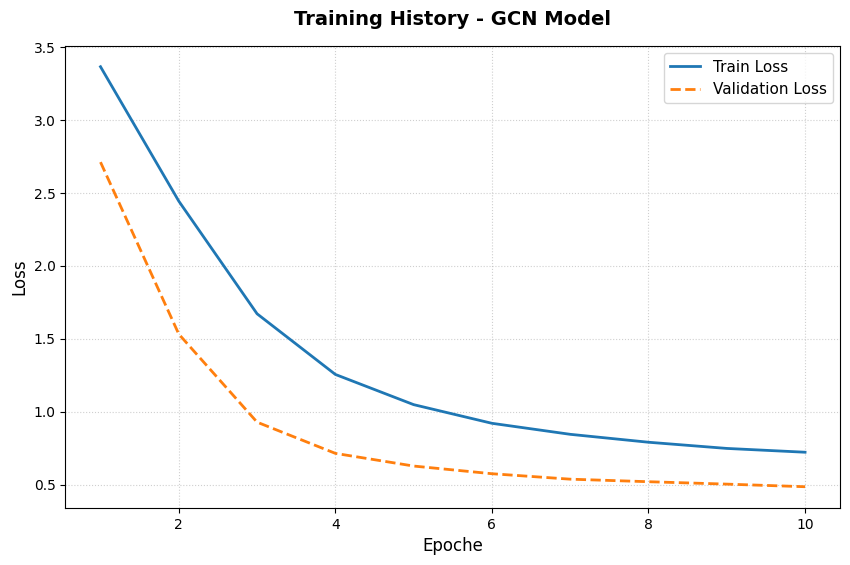

In [ ]:
from utils_task1 import plot_history

plot_history(history, title="Training History - GCN Model")

In [ ]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-Macro: {test_stats.f1_macro:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-Macro: {test_stats.precision_macro:.2f} |"
    f"Test Recall-Macro: {test_stats.recall_macro:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Test Loss: 0.4896 |Test F1-Macro: 0.86 |Test Balanced Acc: 0.88 |Test Precision-Macro: 0.86 |Test Recall-Macro: 0.88 |


Tentativo con SAGEConv

In [ ]:
from utils_task1 import SAGEConvModel

model = SAGEConvModel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_SAGE.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 01/10 | Loss Train: 3.62 | Val Loss: 3.36 | Val F1 Macro: 0.11 | Val Precision: 0.17 | Val Recall: 0.17 |Val Balanced Acc: 0.17
  → Nuovo best model salvato (val_loss=3.3646)


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 02/10 | Loss Train: 3.02 | Val Loss: 2.28 | Val F1 Macro: 0.25 | Val Precision: 0.39 | Val Recall: 0.34 |Val Balanced Acc: 0.34
  → Nuovo best model salvato (val_loss=2.2758)


...

Epoca: 06/10 | Loss Train: 1.13 | Val Loss: 0.64 | Val F1 Macro: 0.83 | Val Precision: 0.82 | Val Recall: 0.85 |Val Balanced Acc: 0.85
  → Nuovo best model salvato (val_loss=0.6382)


Epoca: 07/10 | Loss Train: 0.98 | Val Loss: 0.55 | Val F1 Macro: 0.85 | Val Precision: 0.84 | Val Recall: 0.87 |Val Balanced Acc: 0.87
  → Nuovo best model salvato (val_loss=0.5527)


Epoca: 08/10 | Loss Train: 0.86 | Val Loss: 0.51 | Val F1 Macro: 0.86 | Val Precision: 0.85 | Val Recall: 0.88 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.5062)


Epoca: 09/10 | Loss Train: 0.80 | Val Loss: 0.47 | Val F1 Macro: 0.87 | Val Precision: 0.86 | Val Recall: 0.89 |Val Balanced Acc: 0.89
  → Nuovo best model salvato (val_loss=0.4726)


Epoca: 10/10 | Loss Train: 0.73 | Val Loss: 0.44 | Val F1 Macro: 0.87 | Val Precision: 0.86 | Val Recall: 0.89 |Val Balanced Acc: 0.89
  → Nuovo best model salvato (val_loss=0.4437)


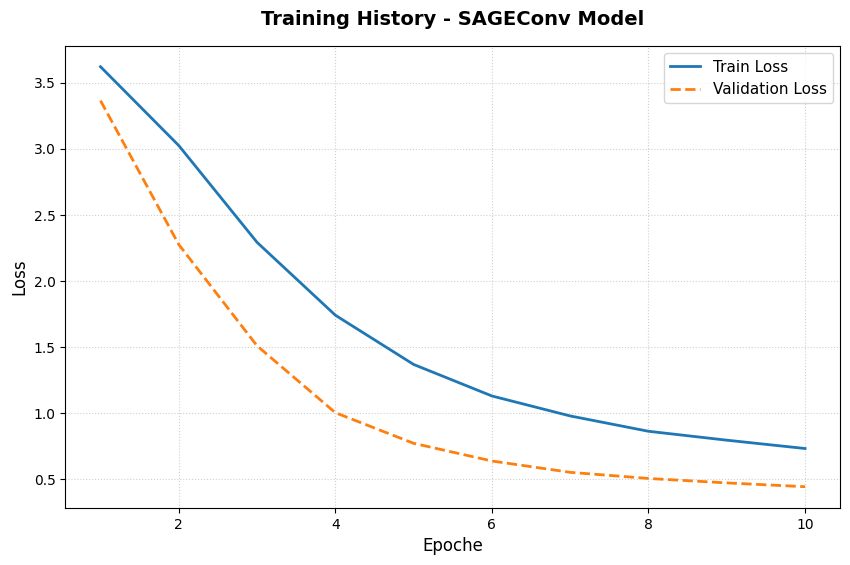

In [ ]:
from utils_task1 import plot_history

plot_history(history, title="Training History - SAGEConv Model")

In [ ]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-Macro: {test_stats.f1_macro:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-Macro: {test_stats.precision_macro:.2f} |"
    f"Test Recall-Macro: {test_stats.recall_macro:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Valutazione...:   0%|          | 0/28 [00:00<?, ?it/s]

Test Loss: 0.4556 |Test F1-Macro: 0.87 |Test Balanced Acc: 0.90 |Test Precision-Macro: 0.86 |Test Recall-Macro: 0.90 |


Tentativo con GATConv

In [ ]:
from utils_task1 import GATModel

model = GATModel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_GAT.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 01/10 | Loss Train: 3.64 | Val Loss: 3.49 | Val F1 Macro: 0.12 | Val Precision: 0.18 | Val Recall: 0.19 |Val Balanced Acc: 0.19
  → Nuovo best model salvato (val_loss=3.4950)


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 02/10 | Loss Train: 3.27 | Val Loss: 2.81 | Val F1 Macro: 0.18 | Val Precision: 0.27 | Val Recall: 0.28 |Val Balanced Acc: 0.28
  → Nuovo best model salvato (val_loss=2.8141)


...

Epoca: 06/10 | Loss Train: 1.53 | Val Loss: 1.05 | Val F1 Macro: 0.76 | Val Precision: 0.78 | Val Recall: 0.79 |Val Balanced Acc: 0.79
  → Nuovo best model salvato (val_loss=1.0495)


Epoca: 07/10 | Loss Train: 1.33 | Val Loss: 0.89 | Val F1 Macro: 0.79 | Val Precision: 0.80 | Val Recall: 0.82 |Val Balanced Acc: 0.82
  → Nuovo best model salvato (val_loss=0.8888)


Epoca: 08/10 | Loss Train: 1.18 | Val Loss: 0.77 | Val F1 Macro: 0.83 | Val Precision: 0.83 | Val Recall: 0.84 |Val Balanced Acc: 0.84
  → Nuovo best model salvato (val_loss=0.7736)


Epoca: 09/10 | Loss Train: 1.07 | Val Loss: 0.69 | Val F1 Macro: 0.83 | Val Precision: 0.83 | Val Recall: 0.85 |Val Balanced Acc: 0.85
  → Nuovo best model salvato (val_loss=0.6901)


Epoca: 10/10 | Loss Train: 0.98 | Val Loss: 0.63 | Val F1 Macro: 0.85 | Val Precision: 0.84 | Val Recall: 0.86 |Val Balanced Acc: 0.86
  → Nuovo best model salvato (val_loss=0.6345)


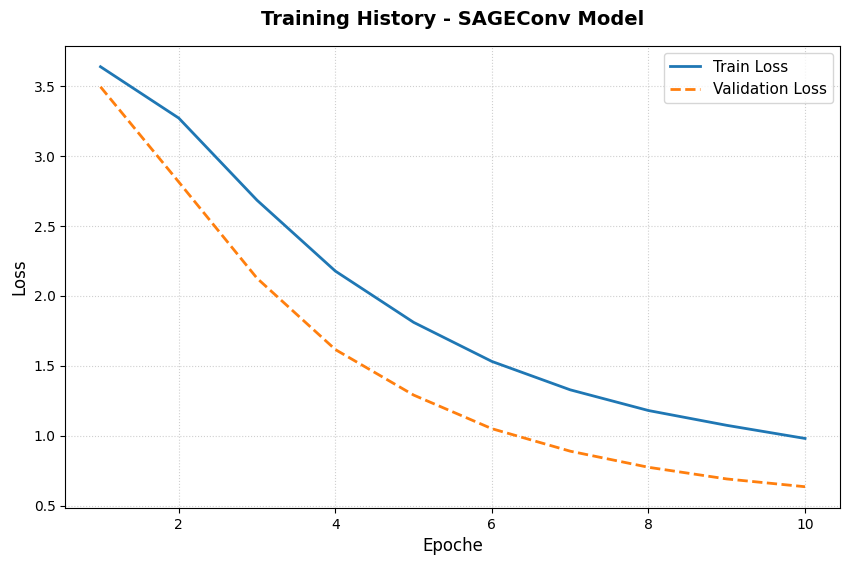

In [ ]:
from utils_task1 import plot_history

plot_history(history, title="Training History - SAGEConv Model")

In [16]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-Macro: {test_stats.f1_macro:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-Macro: {test_stats.precision_macro:.2f} |"
    f"Test Recall-Macro: {test_stats.recall_macro:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Test Loss: 0.6362 |Test F1-Macro: 0.85 |Test Balanced Acc: 0.86 |Test Precision-Macro: 0.85 |Test Recall-Macro: 0.86 |
